# Deep Learning for State Poverty Rate Prediction

**Objective:** Apply deep learning methods to predict US state poverty rates using socio-economic predictors.

**Methodology:** Following the approach from the Somalia poverty study (Nature Scientific Reports 2024), we implement:
- Neural Networks with keras
- Random Forest for comparison
- Feature importance analysis
- Model performance evaluation (RMSE, R², MAE)

**Data:** State-level cross-sectional data (n=50) for 2023

## 1. Setup and Data Loading

In [52]:
# Install required packages
install.packages(c("keras3", "tidyverse", "randomForest", "caret", "MLmetrics", "gridExtra"))

library(keras3)
library(tidyverse)
library(caret)
library(MLmetrics)

trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/keras3_1.5.1.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/tidyverse_2.0.0.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/randomForest_4.7-1.2.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/caret_7.0-1.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/MLmetrics_1.1.3.tgz'
trying URL 'https://cran.rstudio.com/bin/macosx/sonoma-arm64/contrib/4.6/gridExtra_2.3.1.tgz'



The downloaded binary packages are in
	/var/folders/zm/_0b9h87s3hz5gs_zytrkxl5w0000gn/T//Rtmpz0A3mV/downloaded_packages


In [53]:
data <- read_csv("/Users/yeonjune.kim.27/Desktop/Data Science Academy/PROJECT/data/processed/dataset.csv")
# Display structure
summary(data)

Rows: 51 Columns: 31
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): State
dbl (30): pop_dens, unemploy_rate, avg_rent, apart_size, log_income, avg_wage_hr, log_med_home_price, avg_live_conver, avg_live_groc, avg_live_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


       State       pop_dens       unemploy_rate      avg_rent      apart_size      log_income     avg_wage_hr    log_med_home_price
 Length   :51   Min.   :    1.0   Min.   :2.100   Min.   : 919   Min.   :471.0   Min.   :4.706   Min.   :24.43   Min.   :5.360     
 N.unique :51   1st Qu.:   47.5   1st Qu.:3.400   1st Qu.:1129   1st Qu.:669.5   1st Qu.:4.784   1st Qu.:29.26   1st Qu.:5.455     
 N.blank  : 0   Median :  106.0   Median :4.200   Median :1364   Median :698.0   Median :4.812   Median :31.21   Median :5.590     
 Min.nchar: 4   Mean   :  412.1   Mean   :4.067   Mean   :1480   Mean   :690.1   Mean   :4.824   Mean   :32.40   Mean   :5.598     
 Max.nchar:20   3rd Qu.:  226.5   3rd Qu.:4.650   3rd Qu.:1736   3rd Qu.:720.5   3rd Qu.:4.855   3rd Qu.:34.44   3rd Qu.:5.700     
                Max.   :11011.0   Max.   :6.100   Max.   :3085   Max.   :766.0   Max.   :5.045   Max.   :53.37   Max.   :5.990     
 avg_live_conver  avg_live_groc   avg_live_hous    avg_live_uti   log_avg_li

## 2. Data Preparation

In [54]:
# Remove State column (keep only numeric predictors and outcome)
# Outcome variable is 'poverty'
data_clean <- data %>%
  select(-State) %>%
  na.omit()

# Check final dimensions
cat("Final dataset:", nrow(data_clean), "observations,", ncol(data_clean), "variables\n")
cat("Outcome variable: poverty\n")
cat("Number of predictors:", ncol(data_clean) - 1, "\n")

Final dataset: 51 observations, 30 variables
Outcome variable: poverty
Number of predictors: 29 


In [55]:
# Train-test split (80-20)
set.seed(2026)
train_idx <- sample(1:nrow(data_clean), size = 0.8 * nrow(data_clean))

train_data <- data_clean[train_idx, ]
test_data <- data_clean[-train_idx, ]

cat("Training set:", nrow(train_data), "observations\n")
cat("Test set:", nrow(test_data), "observations\n")

Training set: 40 observations
Test set: 11 observations


In [56]:
# Separate X and y
# Outcome variable is 'poverty'
X_train <- train_data %>% select(-poverty) %>% as.matrix()
y_train <- train_data$poverty

X_test <- test_data %>% select(-poverty) %>% as.matrix()
y_test <- test_data$poverty

In [57]:

# Normalize features (standardization)
# Explicitly calling caret to ensure the function is found
preproc <- caret::preProcess(X_train, method = c("center", "scale"))
X_train_scaled <- predict(preproc, X_train)
X_test_scaled <- predict(preproc, X_test)

## 3. Neural Network Model


In [58]:
# Define neural network architecture
# Simple feedforward network with 2 hidden layers
nn_model <- keras_model_sequential() %>%
  layer_dense(units = 64, activation = "relu", input_shape = ncol(X_train_scaled)) %>%
  layer_dropout(rate = 0.25) %>%
  layer_dense(units = 32, activation = "relu") %>%
  layer_dropout(rate = 0.25) %>%
  layer_dense(units = 1)  # Output layer for regression

summary(nn_model)

Model: "sequential_6"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                    ┃ Output Shape                                    ┃                     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                                                │ (None, 64)                                      │                       1,920 │
├─────────────────────────────────────────────────────────────────┼─────────────────────────────────────────────────┼─────────────────────────────┤
│ dropout_12 (Dropout)                                            │ (None, 64)                                      │                           0 │
├─────────────────────────────────────────────────────────────────┼───────────────────────

In [59]:
# Compile model
nn_model %>% compile(
  loss = "mse",
  optimizer = optimizer_adam(learning_rate = 0.001),
  metrics = c("mae")
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 91.0310 - mae: 9.1482 - val_loss: 63.4819 - val_mae: 7.7864
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 88.7258 - mae: 8.9778 - val_loss: 58.9267 - val_mae: 7.5170
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 80.0859 - mae: 8.5491 - val_loss: 54.8289 - val_mae: 7.2649
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 75.9691 - mae: 8.2665 - val_loss: 50.8537 - val_mae: 7.0090
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 75.7112 - mae: 8.2675 - val_loss: 47.3388 - val_mae: 6.7658
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 71.2799 - mae: 8.0699 - val_loss: 44.0012 - val_mae: 6.5189
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 63.7567 - mae: 7.5562 - val_loss: 40.7389 - val_mae: 6.2598
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 57.9207 - mae: 7.1020 - val_loss: 37.5248 - val_mae: 5.9838
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss

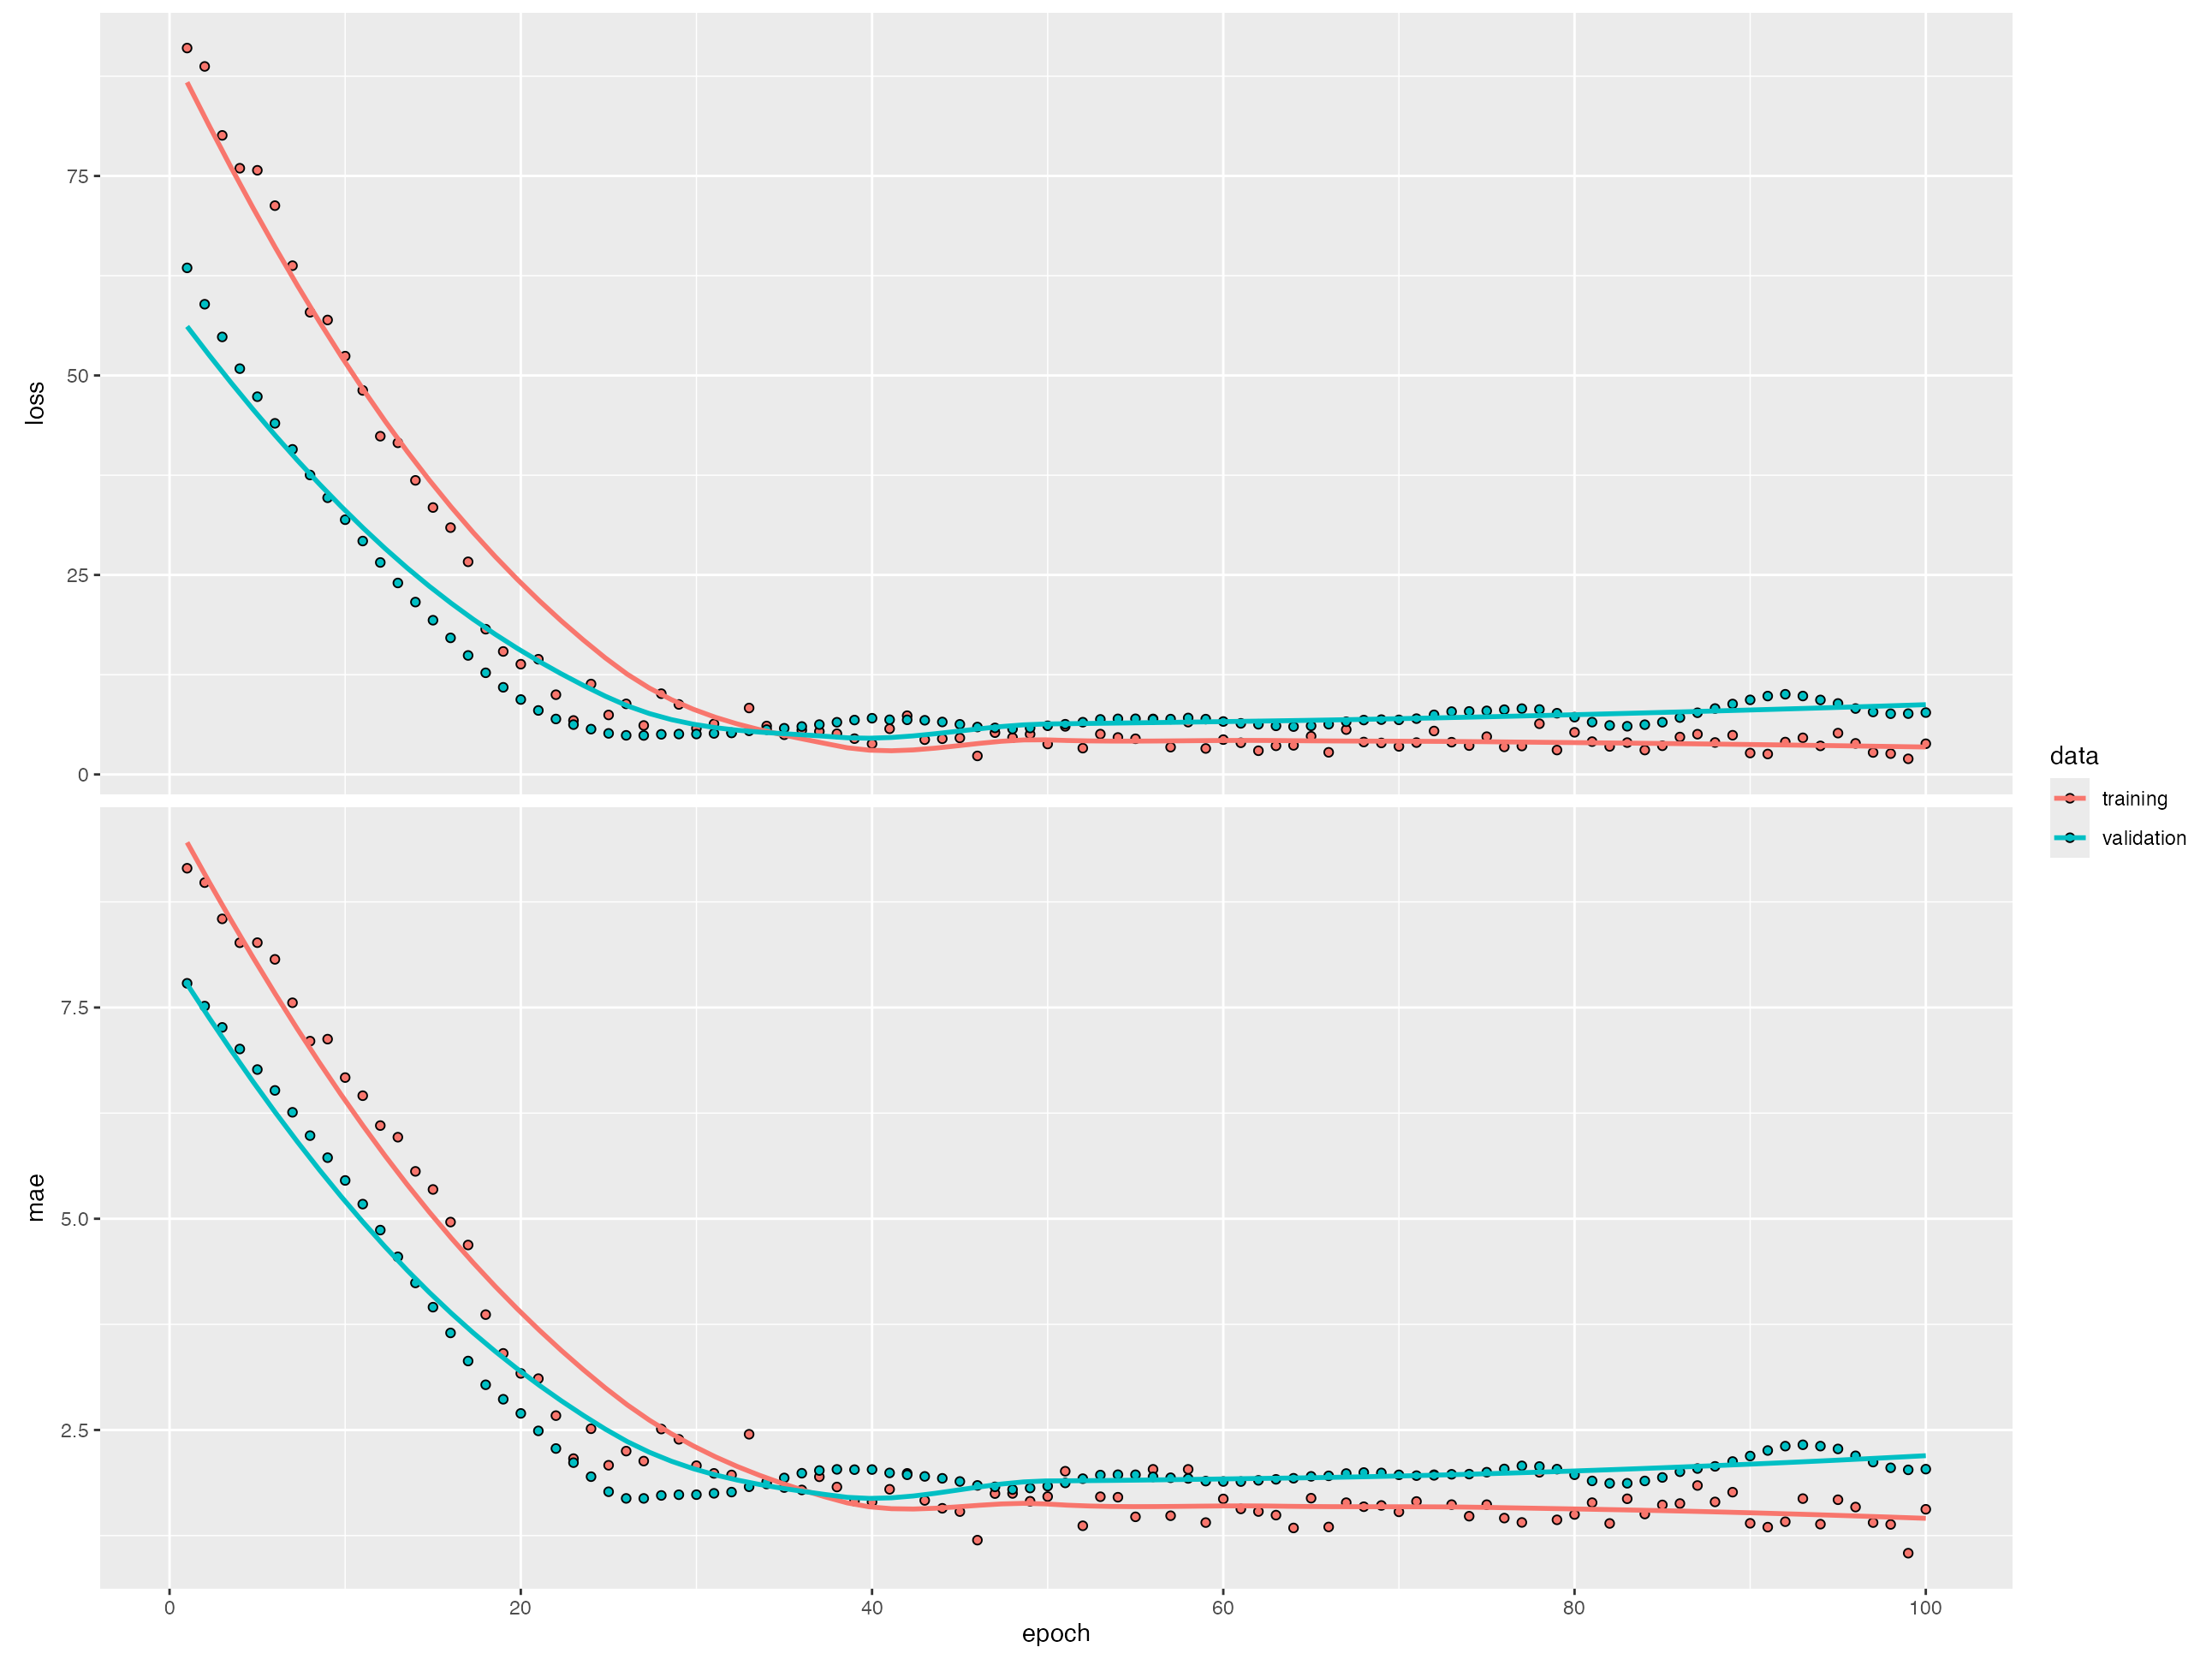

In [60]:
# Train model
history <- nn_model %>% fit(
  X_train_scaled, y_train,
  epochs = 100,
  batch_size = 8,
  validation_split = 0.2,
  verbose = 1
)

plot(history)

In [61]:
summary(nn_model)

Model: "sequential_6"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                    ┃ Output Shape                                    ┃                     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                                                │ (None, 64)                                      │                       1,920 │
├─────────────────────────────────────────────────────────────────┼─────────────────────────────────────────────────┼─────────────────────────────┤
│ dropout_12 (Dropout)                                            │ (None, 64)                                      │                           0 │
├─────────────────────────────────────────────────────────────────┼───────────────────────


##4. L2 Regularization ##


In [62]:
 l2_lambda <- 0.05 # Regularization strength (can tune this)

  nn_model_l2 <- keras_model_sequential() %>%
    layer_dense(units = 64,
                activation = "relu",
                input_shape = ncol(X_train_scaled),
                kernel_regularizer = regularizer_l2(l2_lambda)) %>%
    layer_dropout(rate = 0.25) %>%
    layer_dense(units = 32,
                activation = "relu",
                kernel_regularizer = regularizer_l2(l2_lambda)) %>%
    layer_dropout(rate = 0.25) %>%
    layer_dense(units = 1,
                kernel_regularizer = regularizer_l2(l2_lambda))

  summary(nn_model_l2)

Model: "sequential_7"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                    ┃ Output Shape                                    ┃                     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                                                │ (None, 64)                                      │                       1,920 │
├─────────────────────────────────────────────────────────────────┼─────────────────────────────────────────────────┼─────────────────────────────┤
│ dropout_14 (Dropout)                                            │ (None, 64)                                      │                           0 │
├─────────────────────────────────────────────────────────────────┼───────────────────────

In [63]:
  # Compile model with L2 regularization
  nn_model_l2 %>% compile(
    loss = "mse",
    optimizer = optimizer_adam(learning_rate = 0.001),
    metrics = c("mae")
  )

In [64]:
  # Train model with L2 regularization
  history_l2 <- nn_model_l2 %>% fit(
    X_train_scaled, y_train,
    epochs = 100,
    batch_size = 8,
    validation_split = 0.2,
    verbose = 1
  )


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - loss: 78.3397 - mae: 8.2332 - val_loss: 60.0508 - val_mae: 7.3187
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 73.2918 - mae: 7.9356 - val_loss: 57.3515 - val_mae: 7.1503
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 72.9221 - mae: 7.9257 - val_loss: 54.5966 - val_mae: 6.9735
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 66.4549 - mae: 7.4483 - val_loss: 51.7780 - val_mae: 6.7868
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 66.7150 - mae: 7.4941 - val_loss: 48.7290 - val_mae: 6.5767
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 60.5632 - mae: 7.0103 - val_loss: 45.7034 - val_mae: 6.3592
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 52.9278 - mae: 6.4672 - val_loss: 42.6679 - val_mae: 6.1296
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 55.0782 - mae: 6.6437 - val_loss: 39.5563 - val_mae: 5.8837
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - los

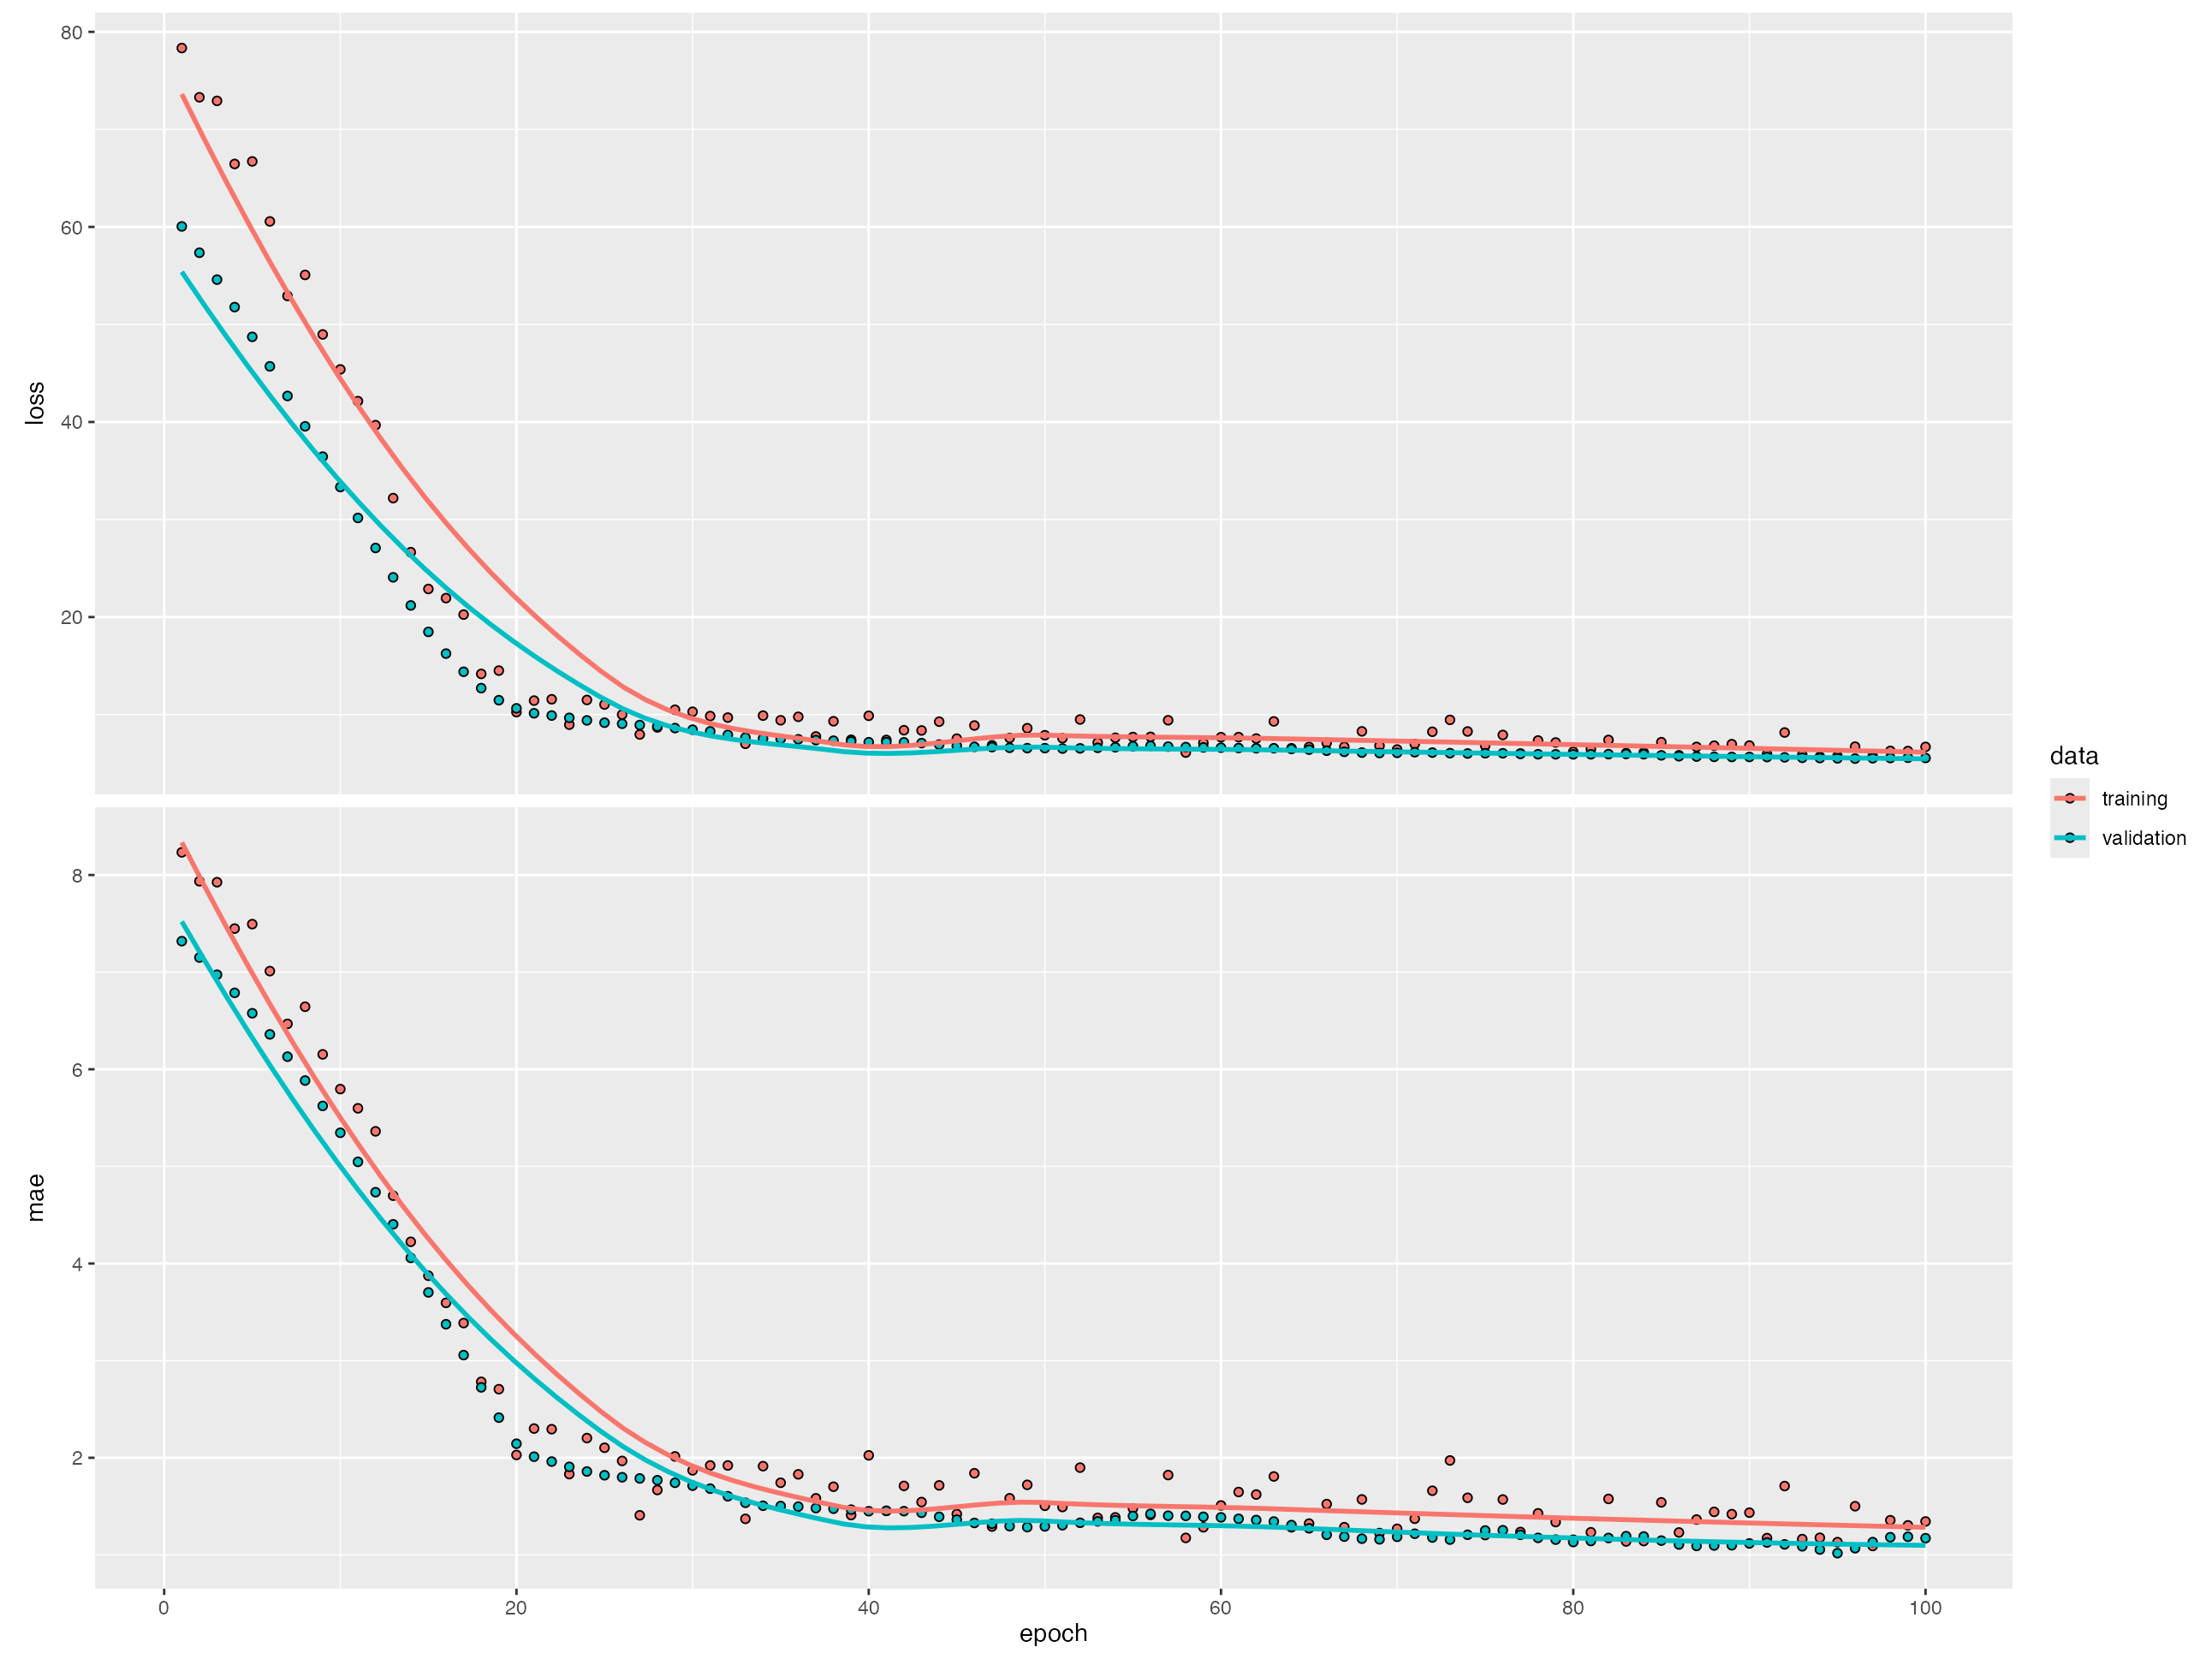

In [65]:
  plot(history_l2)

In [66]:
# Evaluate original model
  pred_original <- nn_model %>% predict(X_test_scaled)
  rmse_original <- sqrt(mean((y_test - pred_original)^2))
  mae_original <- mean(abs(y_test - pred_original))

  # Evaluate L2 regularized model
  pred_l2 <- nn_model_l2 %>% predict(X_test_scaled)
  rmse_l2 <- sqrt(mean((y_test - pred_l2)^2))
  mae_l2 <- mean(abs(y_test - pred_l2))

  # Print comparison
  cat("Original Model:\n")
  cat("  RMSEw:", rmse_original, "\n")
  cat("  MAE:", mae_original, "\n\n")

  cat("L2 Regularized Model:\n")
  cat("  RMSE:", rmse_l2, "\n") #root mean squared error (lower= less bias)
  cat("  MAE:", mae_l2, "\n") #mean absolute error (lower=less bias)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Original Model:
  RMSEw: 1.030197 
  MAE: 0.7437815 

L2 Regularized Model:
  RMSE: 0.8413567 
  MAE: 0.728311 


In [67]:
models_dir <- "/Users/yeonjune.kim.27/Desktop/Data Science Academy/PROJECT/models"                                                                                                         
  if (!dir.exists(models_dir)) {
    dir.create(models_dir, recursive = TRUE)                                                                                                                                                 
  }               

  model_path <- file.path(models_dir, "nn_model_l2_poverty_prediction.keras")
  save_model(nn_model_l2, model_path, overwrite=TRUE)

  cat("Model saved to:", model_path, "\n")

  preproc_path <- file.path(models_dir, "preprocessing_scaler.rds")
  saveRDS(preproc, preproc_path)

  cat("Preprocessing scaler saved to:", preproc_path, "\n")

Model saved to: /Users/yeonjune.kim.27/Desktop/Data Science Academy/PROJECT/models/nn_model_l2_poverty_prediction.keras 
Preprocessing scaler saved to: /Users/yeonjune.kim.27/Desktop/Data Science Academy/PROJECT/models/preprocessing_scaler.rds 
